In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.utils import load_cmapss, add_rul, split_by_engine, get_features_targets 
from sklearn.preprocessing import StandardScaler
df = load_cmapss("../data/raw/train_FD001.txt")
df = add_rul(df, cap=140)

train_df, val_df = split_by_engine(df)

X_train, y_train, X_val, y_val = get_features_targets(train_df, val_df)

# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


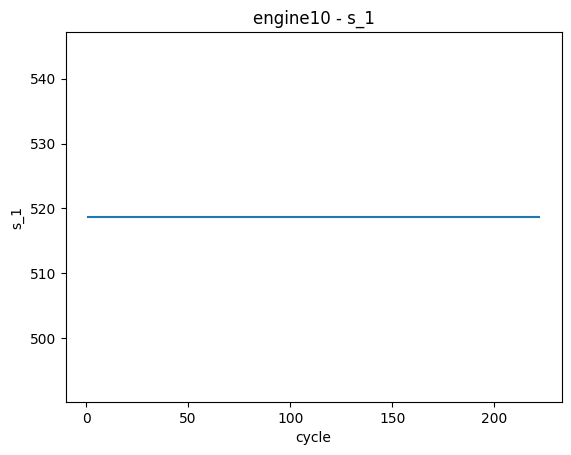

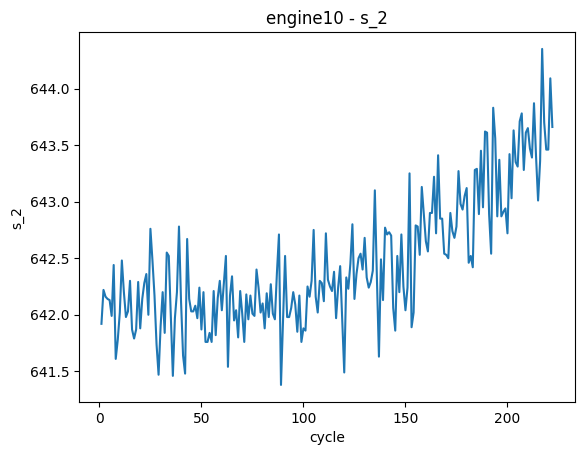

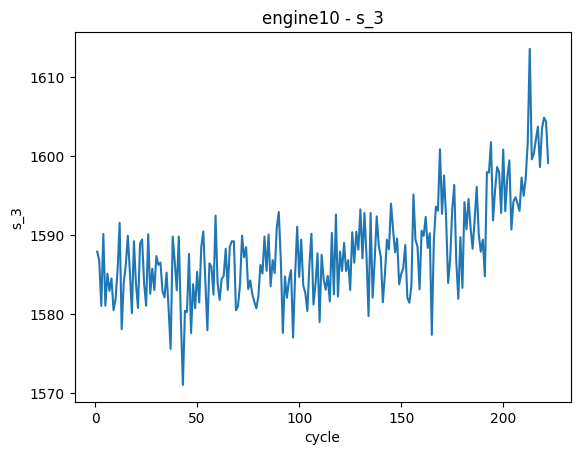

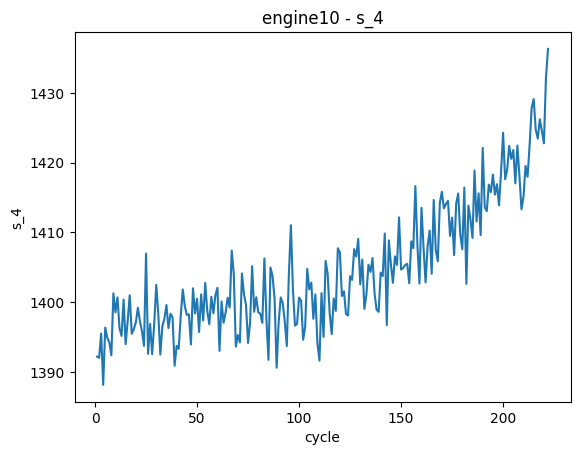

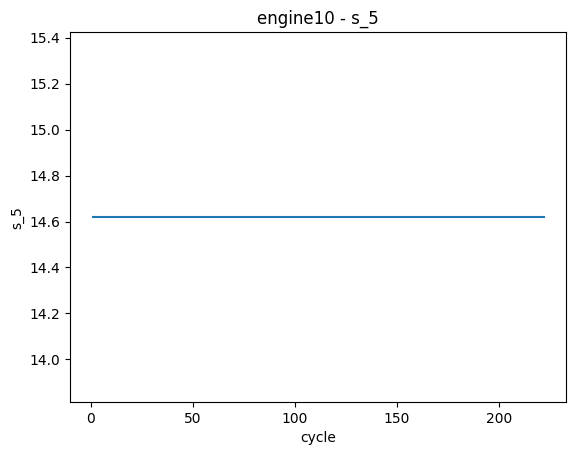

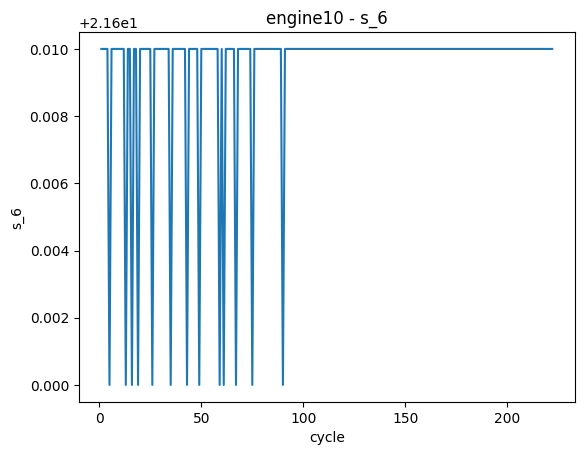

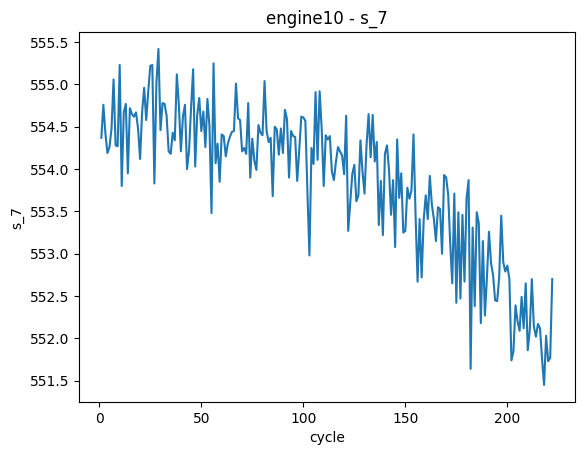

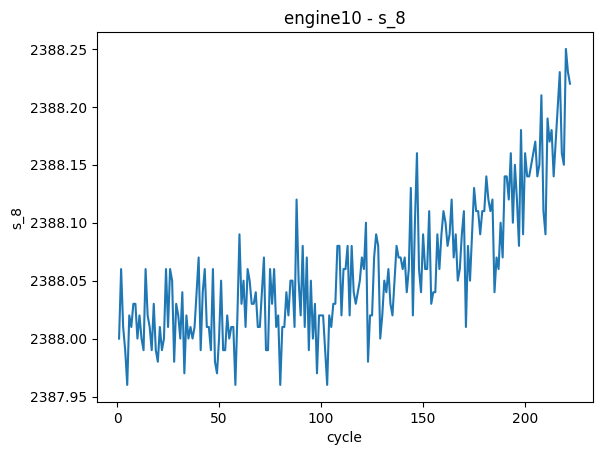

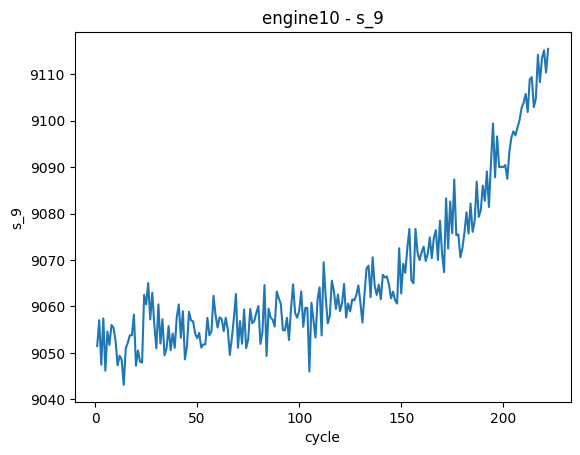

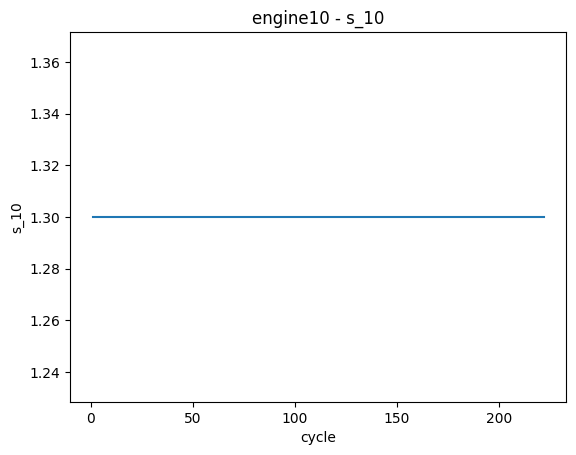

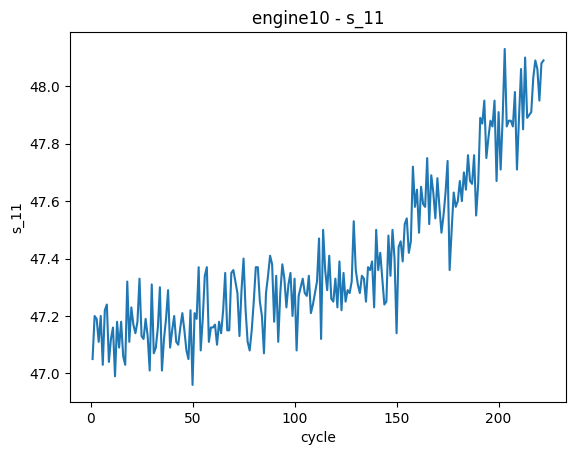

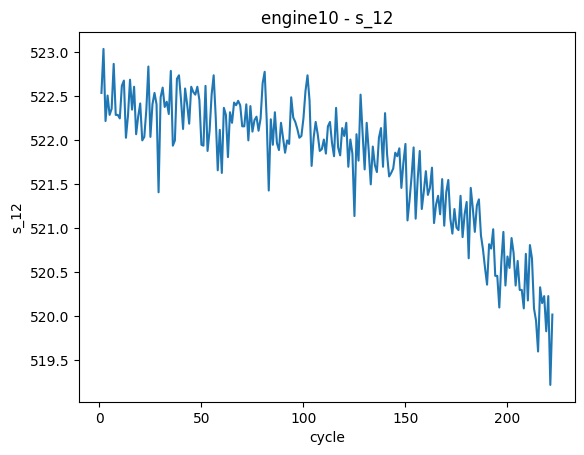

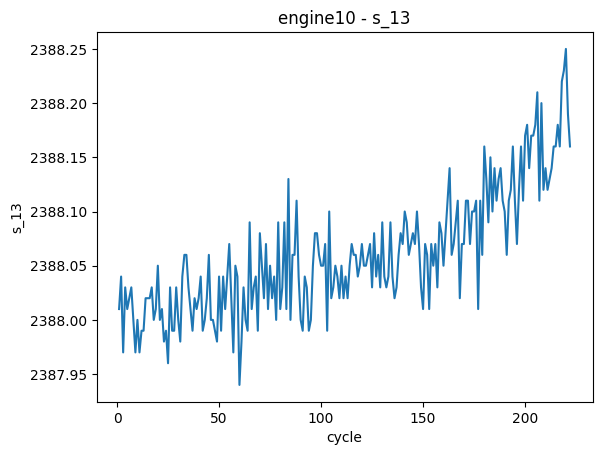

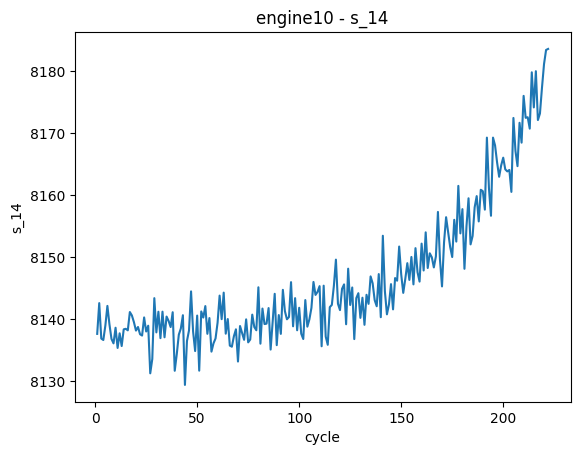

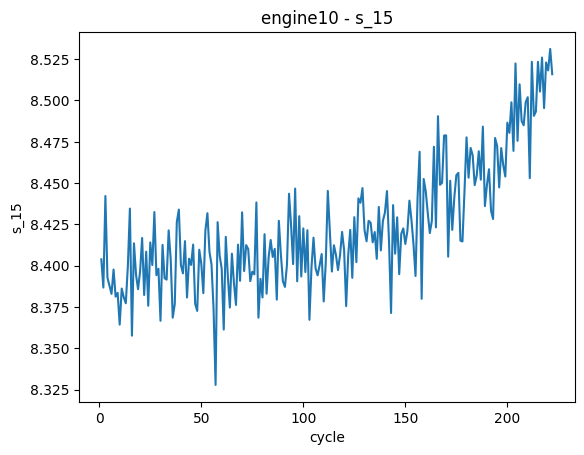

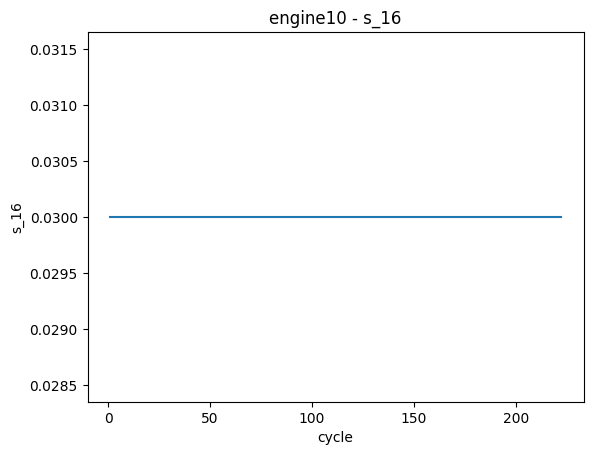

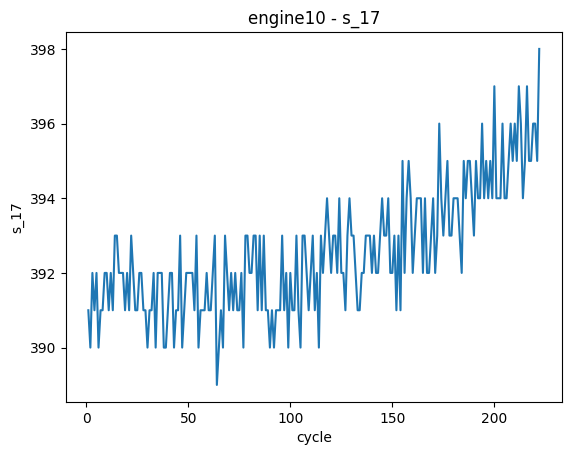

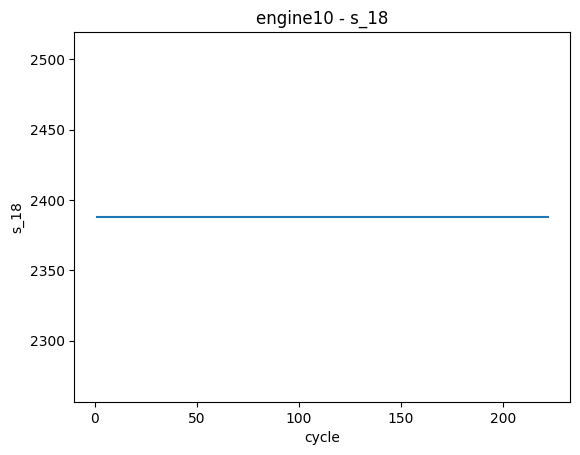

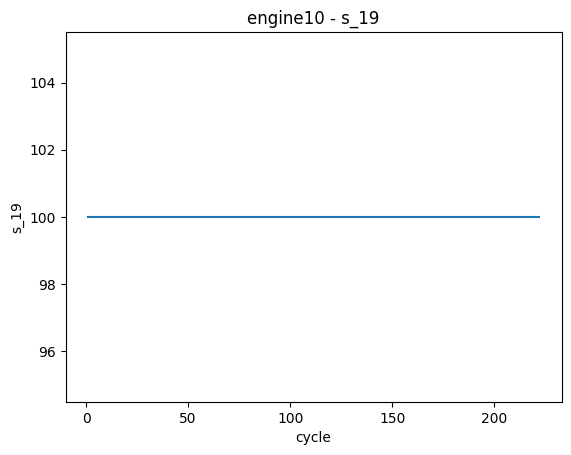

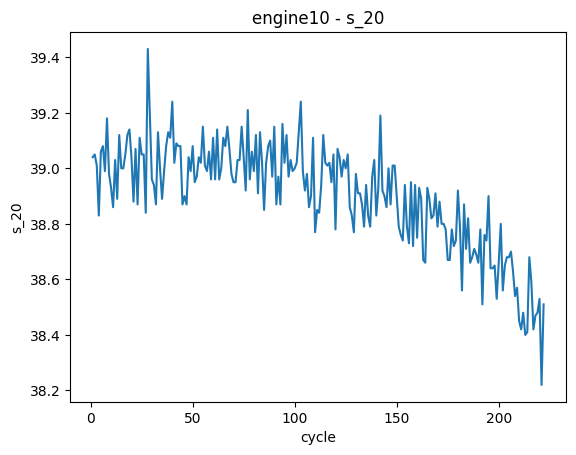

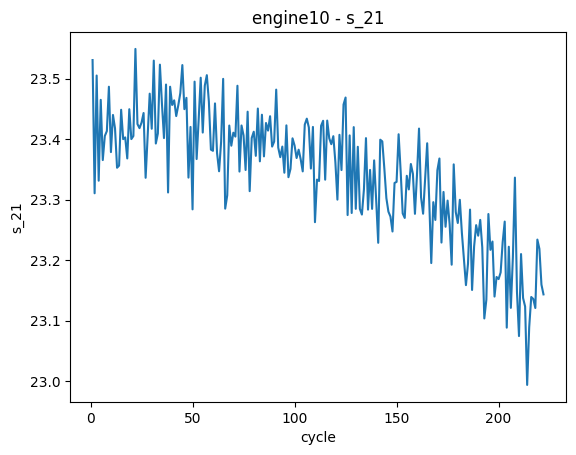

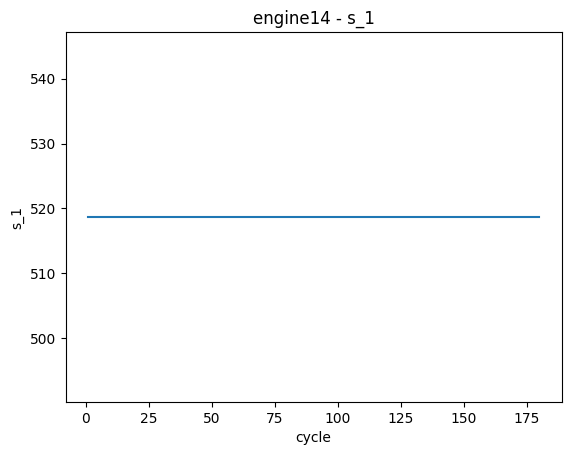

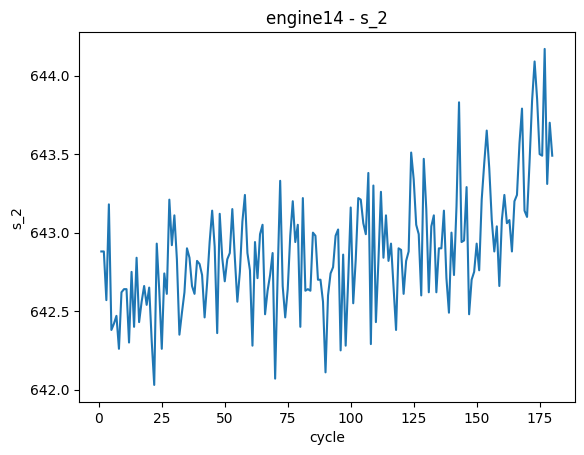

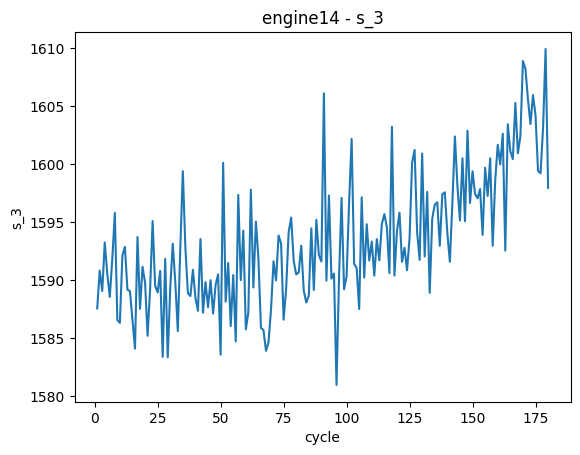

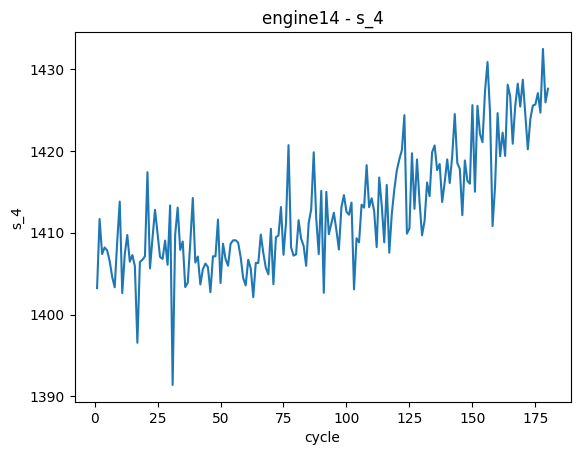

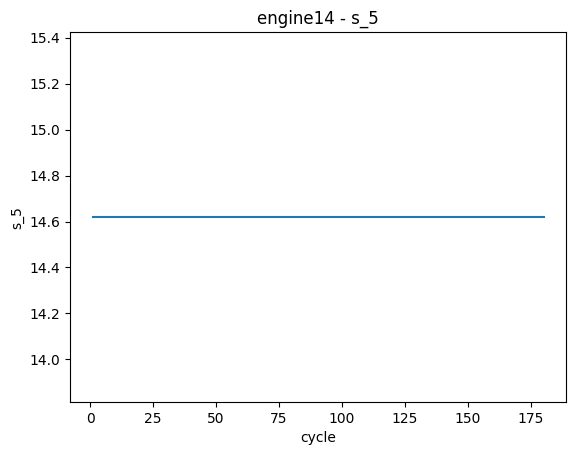

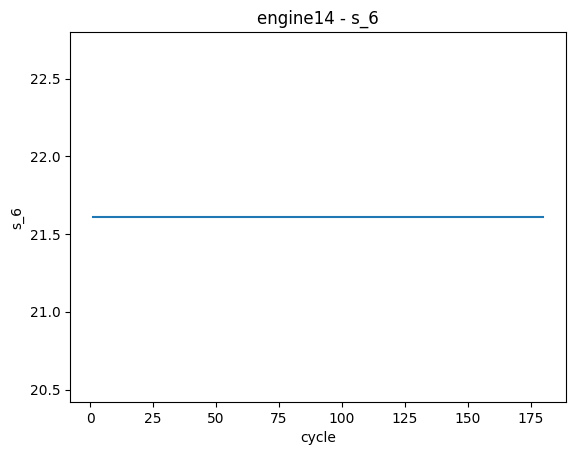

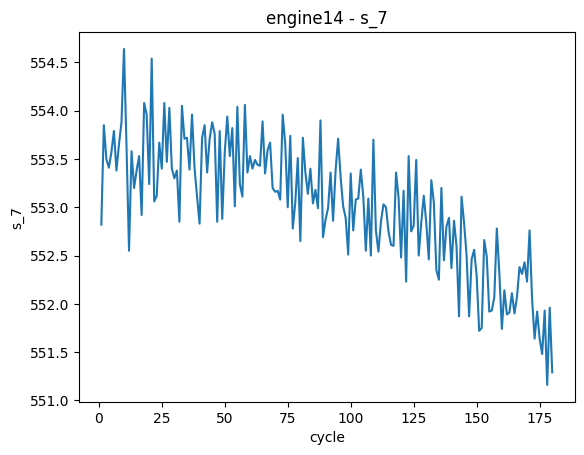

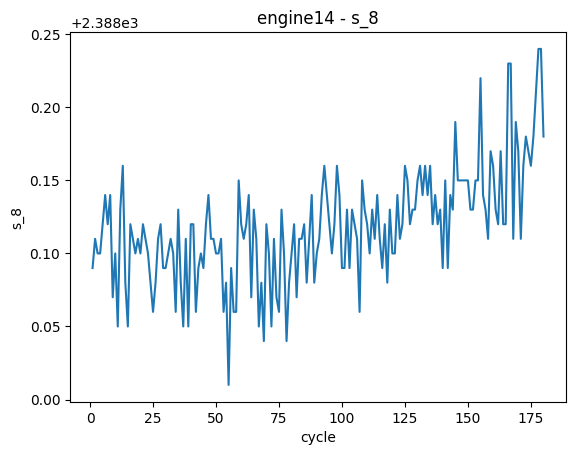

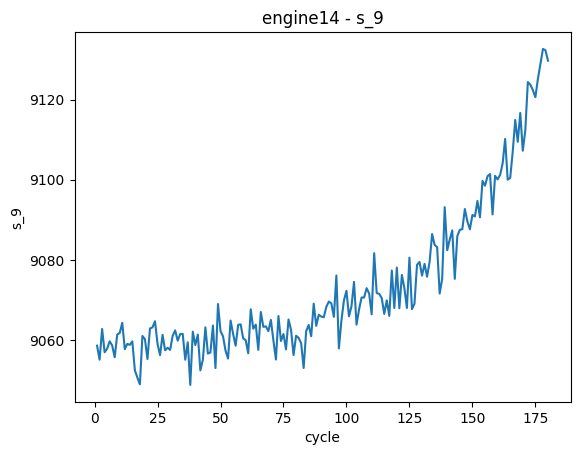

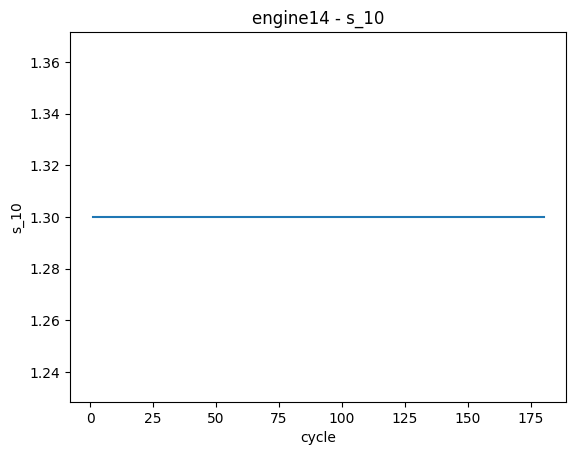

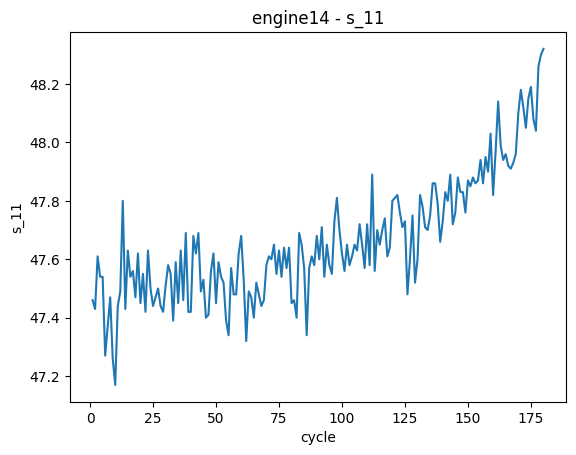

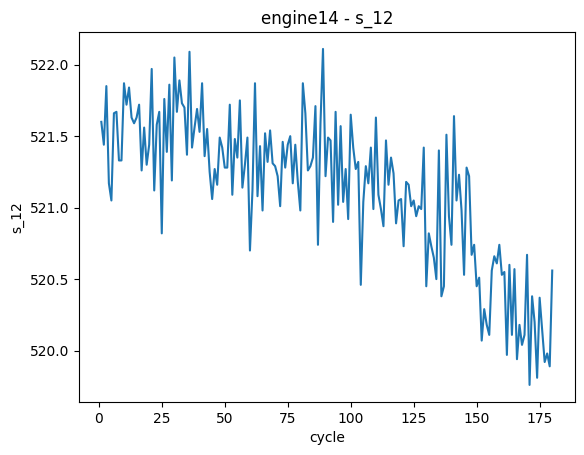

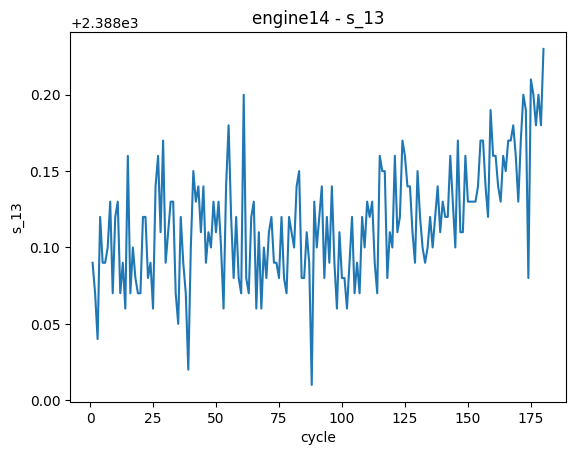

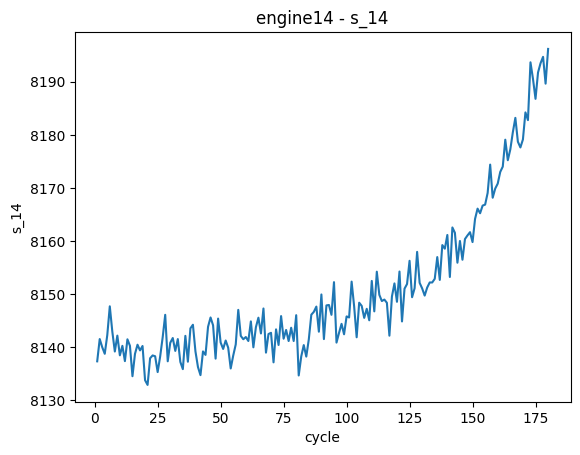

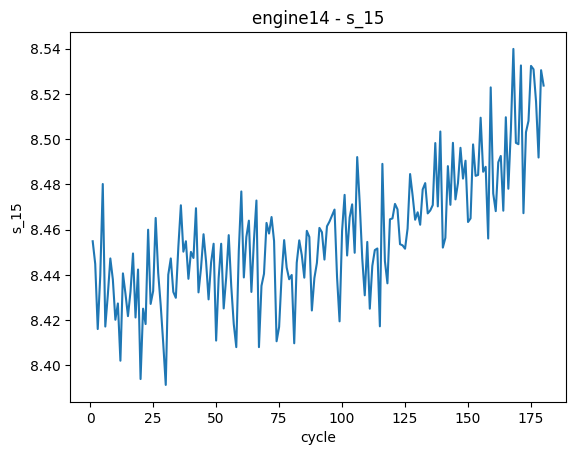

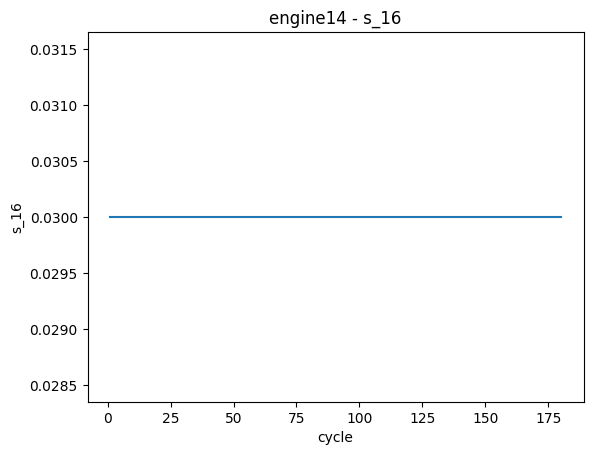

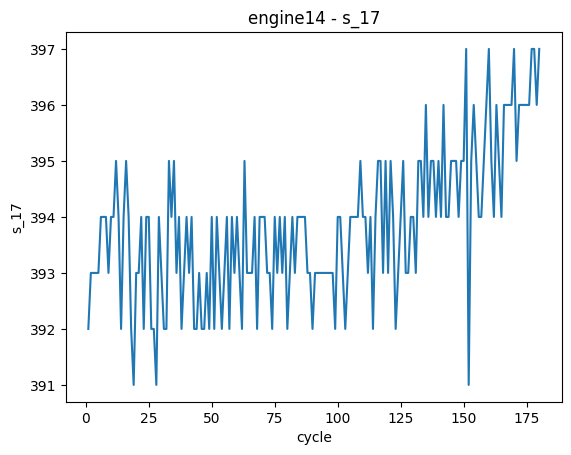

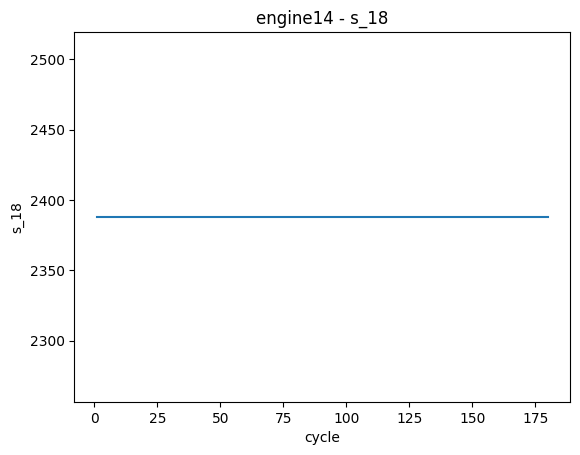

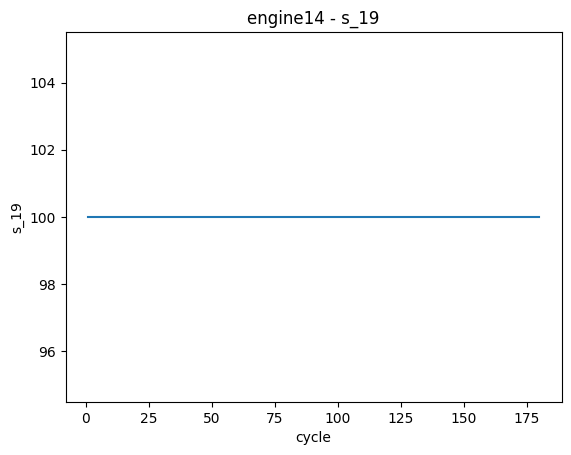

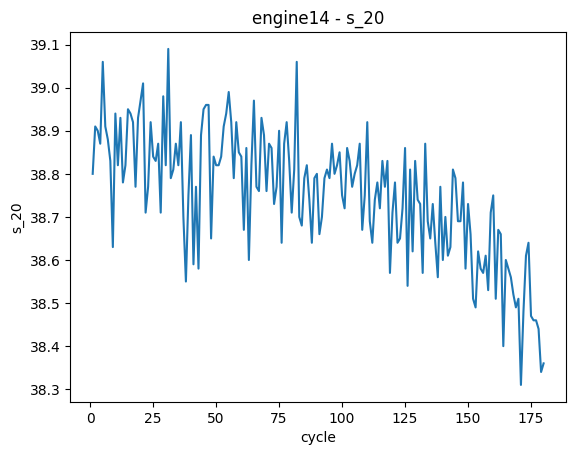

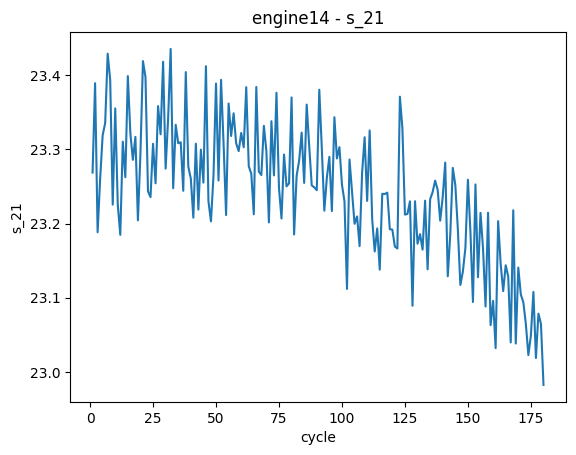

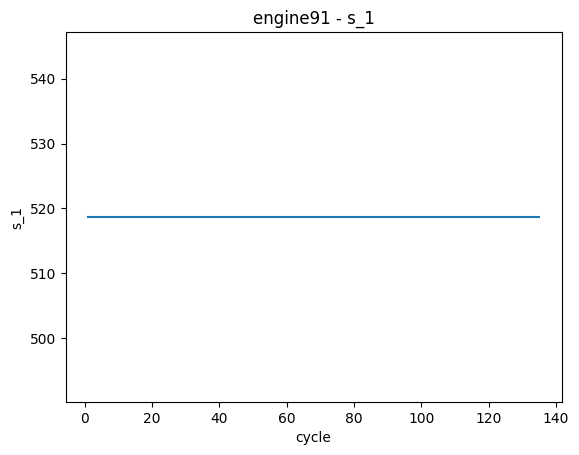

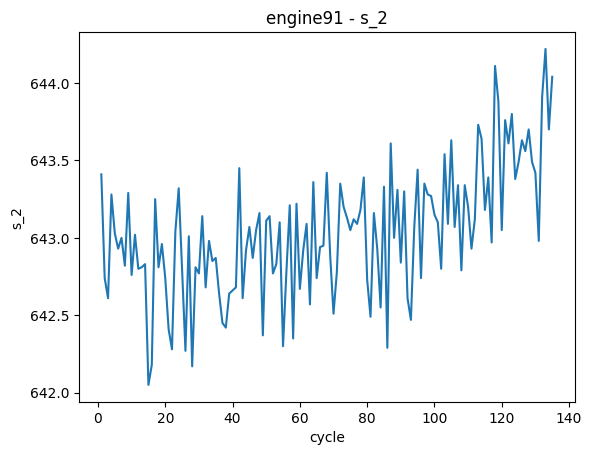

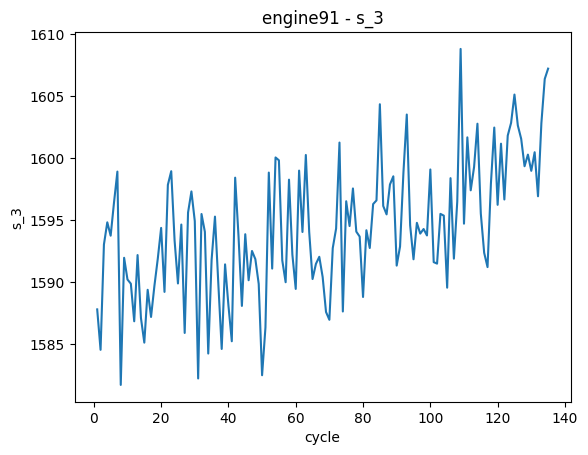

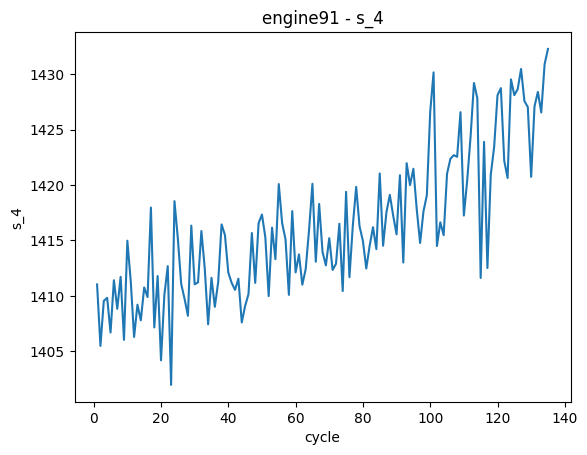

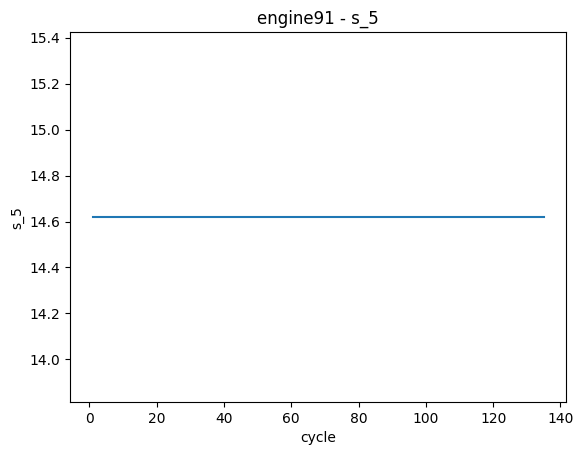

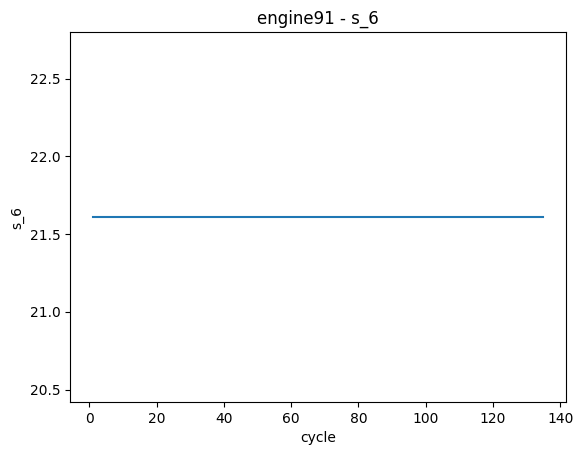

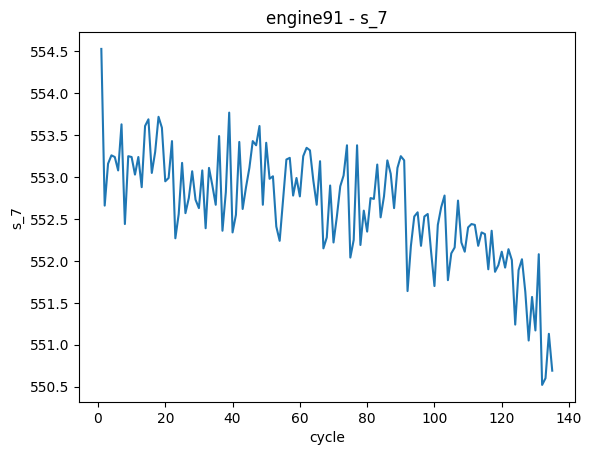

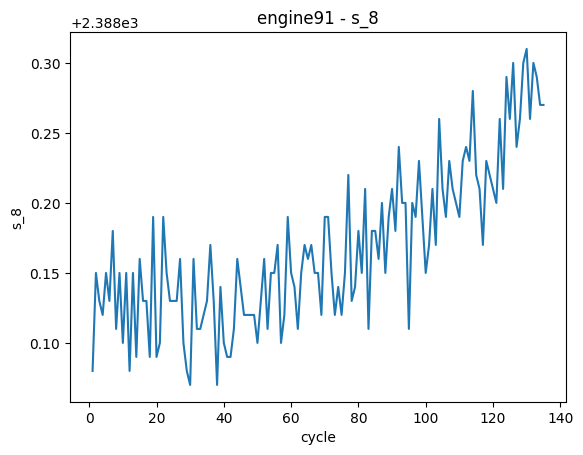

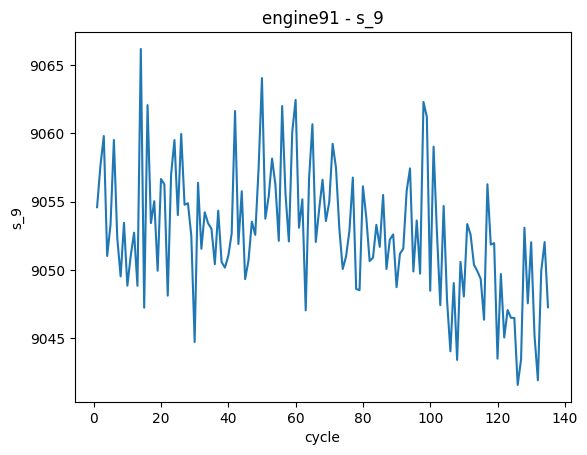

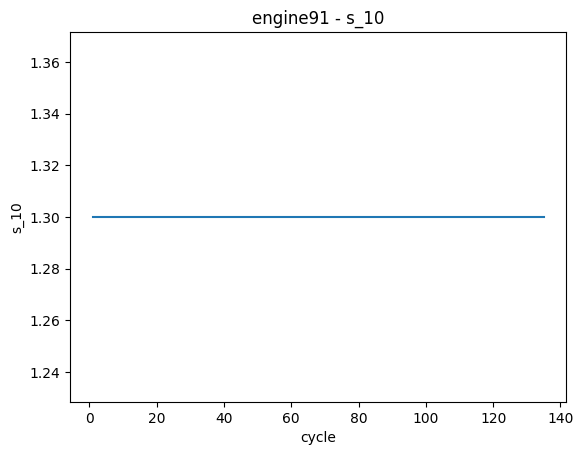

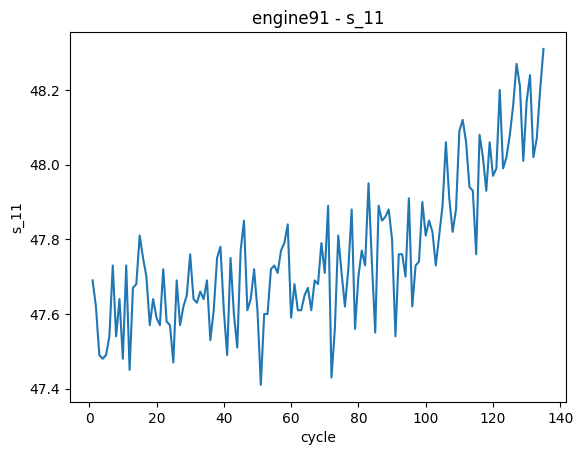

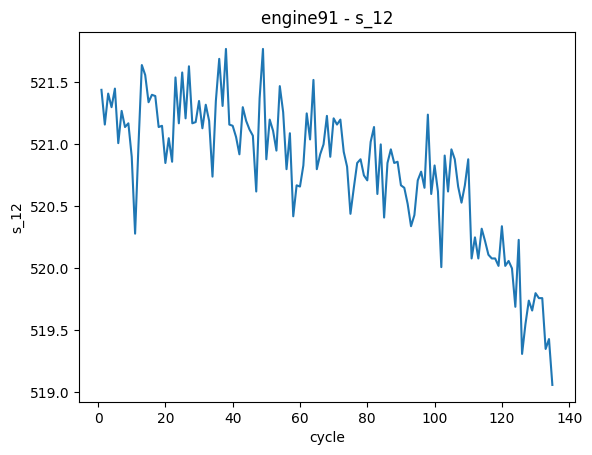

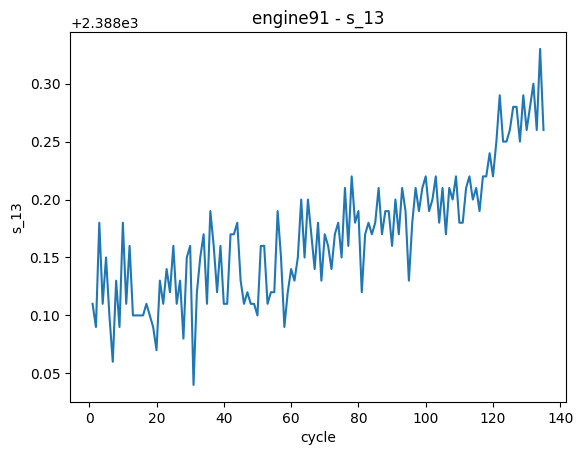

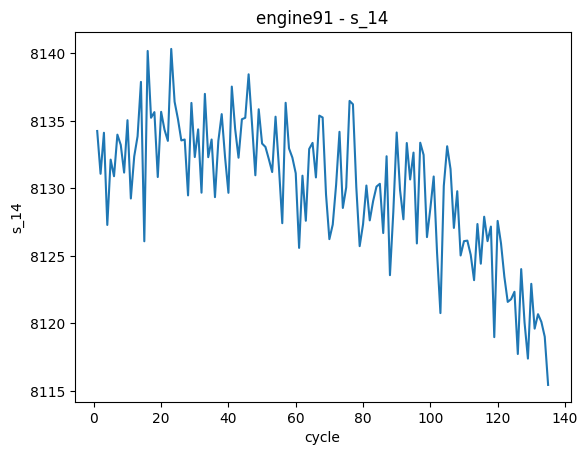

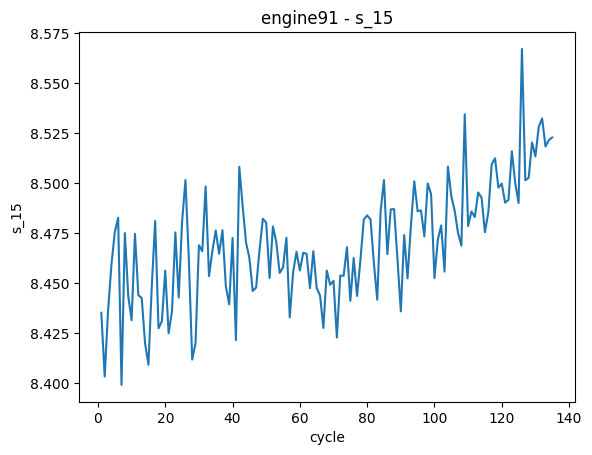

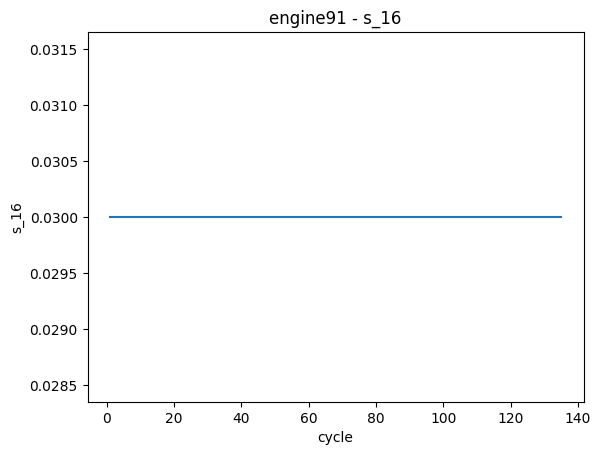

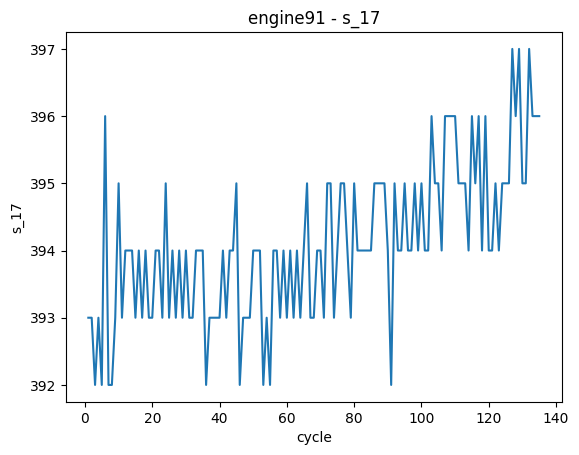

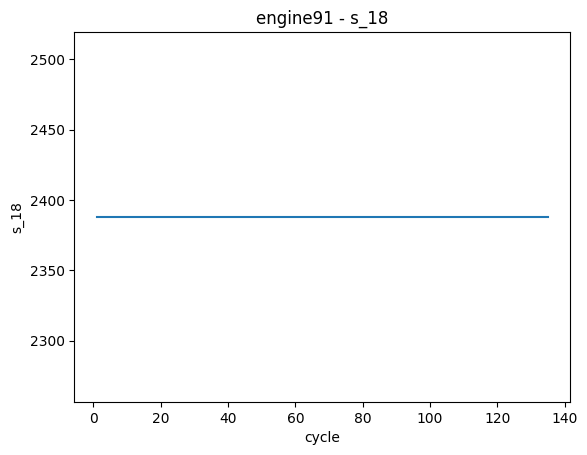

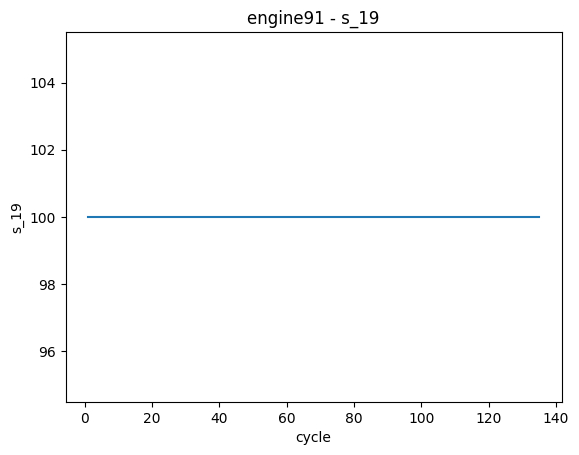

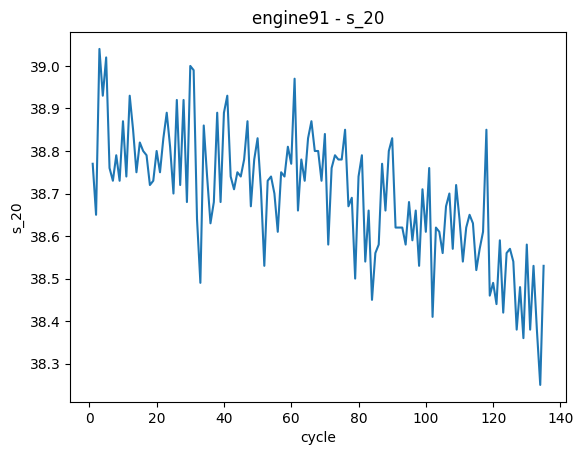

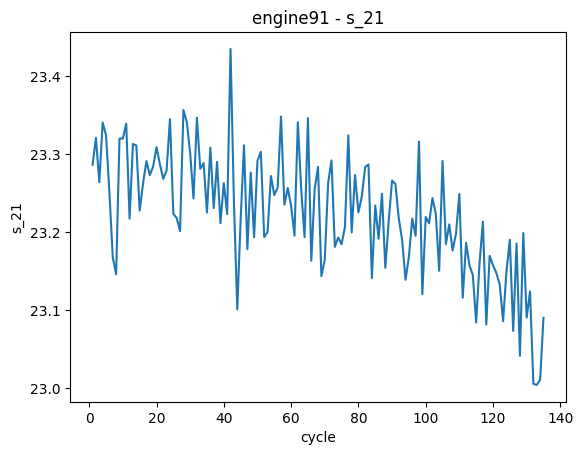

In [2]:
import random
%matplotlib inline
import matplotlib.pyplot as plt
df.columns = df.columns.str.strip()
engine_ids = df['unit'].unique()
sample_engines = random.sample(list(engine_ids),3)
sensor_cols = [col for col in df.columns if col.startswith('s_')]

for engine in sample_engines:
    engine_df = df[df['unit']== engine]
    for sensor in sensor_cols:
        plt.figure()
        plt.plot(engine_df['cycle'],engine_df[sensor])
        plt.title(f'engine{engine} - {sensor}')
        plt.xlabel('cycle')
        plt.ylabel(sensor)
        plt.show()

In [3]:
important = ['s_9','s_14','s_4','s_17']
engine_df = df[df['unit']==32].copy()

for s in important:
    engine_df[s+'_rm'] = engine_df[s].rolling(10, min_periods=1).mean()

In [4]:
from src.utils import compute_slope , recent_slope
slopes = {}
for s in important:
    slopes[s] = compute_slope(engine_df[s].values)
print(slopes)

{'s_9': np.float64(0.17855766051253755), 's_14': np.float64(0.12777852025351338), 's_4': np.float64(0.09858197850647565), 's_17': np.float64(0.014738908790300358)}


In [5]:
slopes = {}
for s in important:
    slopes[s] = recent_slope(engine_df[s].values)
print(slopes)

{'s_9': np.float64(0.7397775305895369), 's_14': np.float64(0.39330144605117506), 's_4': np.float64(0.4220956618464949), 's_17': np.float64(0.05050055617352613)}
